<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/13_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dropout

## Overview

As neural networks become deeper and more complex, they may memorize the training data instead of learning general patterns. This problem is known as **overfitting**, where the model performs well on the training set but performs poorly on unseen data.

**Dropout** is a regularization technique that reduces overfitting by randomly disabling a fraction of neurons during training. Instead of relying on a few important neurons, the network is encouraged to distribute learning across many neurons, resulting in a model that generalizes better.

---



## Why Dropout?

A model can become overly dependent on specific neurons. If those neurons dominate the learning process, the network may fail to generalize to new data.

Dropout helps by:

- Preventing neurons from becoming overly specialized.
- Reducing overfitting.
- Encouraging the network to learn more robust feature representations.

---



## How Dropout Works

During each training iteration:

1. A random subset of neurons is temporarily deactivated.
2. These neurons do not participate in forward propagation.
3. Since they produce no output, they also receive **no gradients** during backpropagation.
4. A different subset of neurons is dropped during the next iteration.

Because the dropped neurons change every iteration, the network cannot rely on any single neuron and instead learns redundant, more general features.

---

## Key Points

- Dropout is applied **only during training**.
- Different neurons are randomly dropped in every iteration.
- The complete network is restored during testing (inference).
- Dropout improves generalization and reduces overfitting.

---



Dropout Rate: The dropout rate specifies the fraction of neurons to deactivate during training. For example, a dropout rate of 0.5 means that approximately 50% of the neurons are randomly disabled during each training iteration.

**Dropout in Practice**

## What Happens During Training?

The figure below illustrates the effect of dropout on a neural network.

**Before Dropout**
- Every hidden neuron participates in computation.
- All neurons contribute to the final prediction.

**After Dropout**
- Some hidden neurons are randomly removed.
- Removed neurons produce no output.
- Their gradients become zero during backpropagation.
- The remaining neurons continue the forward and backward passes.

As a result, the model cannot become overly dependent on any individual neuron.
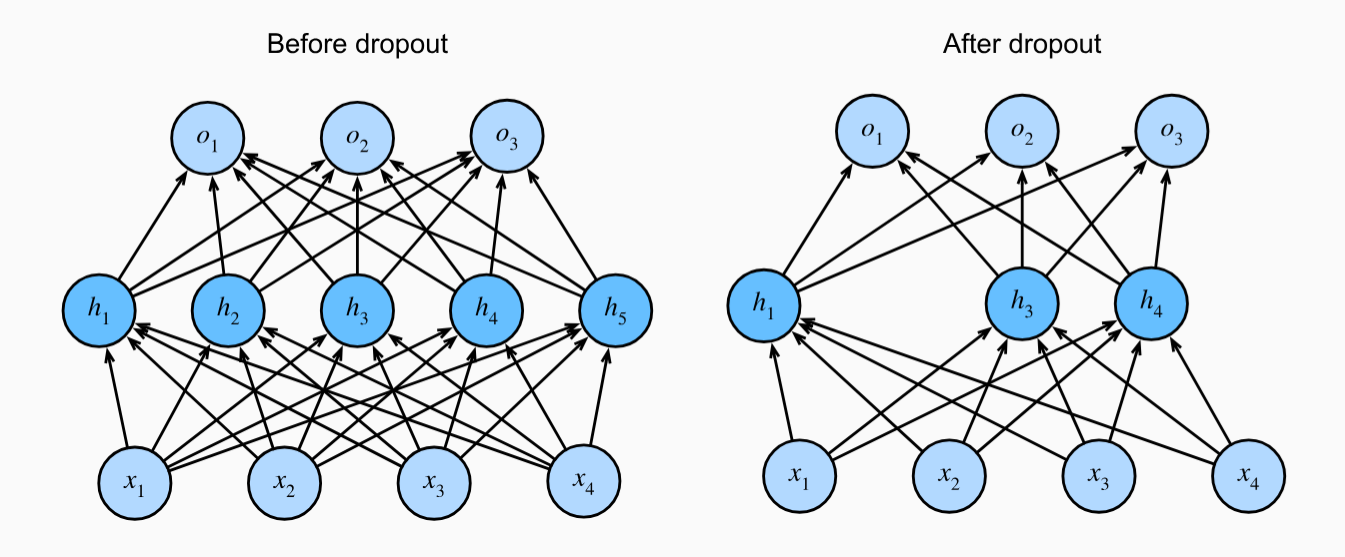

> *MLP before and after dropout.*

---



## Training vs. Testing

### During Training
- Random neurons are dropped.
- Helps reduce overfitting.
- A different network is effectively trained in every iteration.

### During Testing (Inference)
- No neurons are dropped.
- The complete network is used to make predictions.
- This ensures stable and consistent outputs.

---

## Advantages of Dropout

- Reduces overfitting.
- Improves generalization.
- Prevents co-adaptation between neurons.
- Produces more robust feature learning.

---



In this implementation, dropout is applied after each hidden layer and after the ReLU activation, which is the standard practice in modern neural networks.

## **Concise Implementation**

Modern deep learning frameworks provide a built-in **Dropout** layer, eliminating the need to implement the dropout algorithm manually. In TensorFlow, dropout is added as a standard layer within the model architecture.

In the implementation below, a `Dropout` layer is placed after each hidden layer. During training, the specified fraction of neurons is randomly deactivated, while during inference all neurons remain active automatically.

The dropout probability for each hidden layer is specified using the `dropout_1` and `dropout_2` parameters.



In [ ]:
!pip install -q D2L --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 1.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from d2l import tensorflow as d2l

In [ ]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()

        # Save the model hyperparameters
        self.save_hyperparameters()

        # Build the neural network sequentially
        self.net = tf.keras.models.Sequential([

            # Flatten the 28×28 input image into a 784-element vector
            tf.keras.layers.Flatten(),

            # First hidden layer with ReLU activation
            tf.keras.layers.Dense(num_hiddens_1, activation=tf.nn.relu),

            # Randomly deactivate a fraction of neurons during training
            tf.keras.layers.Dropout(dropout_1),

            # Second hidden layer with ReLU activation
            tf.keras.layers.Dense(num_hiddens_2, activation=tf.nn.relu),

            # Apply dropout again to reduce overfitting
            tf.keras.layers.Dropout(dropout_2),

            # Output layer (10 logits for Fashion-MNIST classes)
            tf.keras.layers.Dense(num_outputs)
        ])

Note: The Dropout layers are active only during training. During testing (inference), TensorFlow automatically disables dropout so that all neurons participate in making predictions.

### Training the Model

Training the dropout model follows exactly the same procedure as the previous multilayer perceptron. The only difference is that the Dropout layers are automatically enabled during training and disabled during inference by TensorFlow.


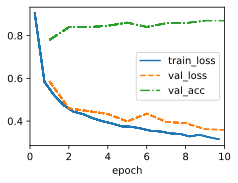

In [ ]:
# Define the loss function for multi-class classification
# Model outputs raw logits (no Softmax)
# Average the loss over each batch
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction="sum_over_batch_size")

# Create the Dropout neural network
model = DropoutMLP(
    num_outputs=10,      # 10 output classes (Fashion-MNIST)
    num_hiddens_1=256,   # First hidden layer
    num_hiddens_2=256,   # Second hidden layer
    dropout_1=0.5,       # Drop 50% of neurons in the first hidden layer
    dropout_2=0.5,       # Drop 50% of neurons in the second hidden layer
    lr=0.1               # Learning rate
)

# Attach the loss function to the model
model.loss = lambda y_hat, y: loss_fn(
    tf.reshape(y, (-1,)),                  # Flatten the true labels
    tf.reshape(y_hat, (-1, y_hat.shape[-1])) # Reshape predictions to (batch_size, 10)
)

# Load the Fashion-MNIST dataset
data = d2l.FashionMNIST(batch_size=256)

# Create a trainer and train the model for 10 epochs
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)



The learning curves above show that the model converges successfully while using dropout regularization to improve generalization and reduce overfitting.



### Key Points

- Dropout is implemented using TensorFlow's built-in `Dropout` layer.
- Dropout is applied only during training.
- During inference, the full network is used without dropping neurons.
- The implementation requires only a few additional lines of code compared to a standard MLP.

In this implementation, dropout is applied after each hidden layer and after the ReLU activation, which is the standard practice in modern neural networks.